In [ ]:



import pickle


import scanpy as sc

import pandas as pd



import matplotlib.pyplot as plt
from matplotlib import colors
# color_map
# sc.settings.set_figure_params(dpi=120)

plt.rcParams['figure.figsize']=(8,8) #rescale figures
# sc.settings.verbosity = 3

sc.set_figure_params(scanpy=True, dpi_save=400,dpi=150)

# plt.rcParams["font.family"] = "Arial"
plt.rcParams['pdf.fonttype'] = 42

import os 


import numpy as np 
import sys


In [2]:
sc.settings.figdir = '../fig3_main_realslices/'

In [3]:
figdir = '../fig3_main_realslices/'

In [4]:
# spa_celltype_key='cell_type'

# 'scrna_cluster_key':
#             'spa_key':'spatial',


dataset = '1'

scrna_cluster_key = "Cell class (determined from clustering of all cells)"

deconv_dir = figdir + dataset + '/deconv/'
metrics_dir = figdir + dataset + '/metrics/'

dataset = 'Moffitt2018'
dataset_full = 'dataset1_merfish_moffitt2018'
pickle_path = '../../datasets/' + dataset_full + '/results/simulations/pickles/'
N = 50
nneigh = 10
nbdswaps = 2
par_lambda_curr = 0.1
# par_eta1_curr = 10.0
kernel3d_bw_slices_curr = 8
bandwidth_curr = 0.01
n_spatial_neigh_curr = 10
mode_nbd = 'variabletranscr'
gtalign = False # if True, use GT alignment 
aligntool = 'moscot'
key_name = 'linear_0'
num_augment = '20'
mode_nbd = 'variabletranscr'
augment = True
mode = 'multislice'
sc_type = 'sc'
suffix = '_normnolog_nov2024_1k'





deconv_dir = figdir  + '/deconv/'
adata_sc = sc.read('../../datasets/' + dataset_full +   "/data/scrna_ref" + suffix + ".h5ad")

cell_type = scrna_cluster_key
celltype_colors = list(adata_sc.uns[cell_type + '_colors'])
celltype_classes  = list(adata_sc.obs[cell_type].cat.categories)


adata_spa_path = pickle_path + 'multi_slice_simulated_' + 'sptsz_' + str(N)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + suffix + '.pickle' # '_old.pickle'        
# read spatial file 
if not os.path.exists(adata_spa_path):
    print(adata_spa_path)
    sys.exit() 
with open(adata_spa_path, 'rb') as handle:
    adata_spa = pickle.load(handle)


key_name = 'linear_0'

result_metric = ['orig_rmse',   'avg_corr_pe','avg_jsd']


all_algos = {}

partesting_str =     '_partesting_' + 'parlambda_' + str(par_lambda_curr) +   '_parbw_' + str(bandwidth_curr) +  '_nbdtype_' + mode_nbd +   '_realalign_' + str(aligntool) 
res_file = 'deconv_' + mode + '_' + mode_nbd + '_sptsz_' + str(N)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + partesting_str +'_sc.pickle'
print(res_file)
with open(deconv_dir + res_file, 'rb') as handle:
    metrics_sc_ms = pickle.load(handle)
all_algos['SpaDecoder'] = metrics_sc_ms

# res_file = 'deconv_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_CARD.pickle'
# with open(deconv_dir + res_file, 'rb') as handle:
#     metrics_card = pickle.load(handle)
# metrics_card = metrics_card['linear_0']
# all_algos['CARD'] = metrics_card


# res_file = 'deconv_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_cell2location.pickle'
# with open(deconv_dir + res_file, 'rb') as handle:
#     metrics_cell2loc = pickle.load(handle)
# metrics_cell2loc = metrics_cell2loc['linear_0']
# all_algos['Cell2location'] = metrics_cell2loc

# res_file = 'deconv_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_tangram.pickle'
# with open(deconv_dir + res_file, 'rb') as handle:
#     metrics_tangram = pickle.load(handle)
# metrics_tangram = metrics_tangram['linear_0']
# all_algos['Tangram'] = metrics_tangram

# res_file = 'deconv_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_tangramsc.pickle'
# with open(deconv_dir + res_file, 'rb') as handle:
#     metrics_tangramsc = pickle.load(handle)
# metrics_tangramsc = metrics_tangramsc['linear_0']
# all_algos['Tangramsc'] = metrics_tangramsc








deconv_multislice_variabletranscr_sptsz_50_nneigh_10_nbdswaps_2_partesting_parlambda_0.1_parbw_0.01_nbdtype_variabletranscr_realalign_moscot_sc.pickle


/tmp/ipykernel_3119602/187443148.py:54: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  adata_spa = pickle.load(handle)
/tmp/ipykernel_3119602/187443148.py:68: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is

In [5]:
adata_all = adata_spa.copy()

In [6]:
slices= list(adata_all['linear_0'][0].keys())
slices = [int(entry) for entry in slices]
slices.sort()


In [7]:
import anndata 
# adata_concat = adata_all['linear_0'][0]['0'].copy(
adata_concat = anndata.AnnData(all_algos['SpaDecoder']['0'][0].T)
adata_concat.obs['sample'] = '0'
# adata_concat.
for realslice in slices[1:]:
    tmp_adata =  anndata.AnnData(all_algos['SpaDecoder'][str(realslice)][0].T)
    tmp_adata.obs['sample'] = str(realslice)

    adata_concat = adata_concat.concatenate(tmp_adata)

/tmp/ipykernel_3119602/2994523725.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_concat = adata_concat.concatenate(tmp_adata)
/tmp/ipykernel_3119602/2994523725.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_concat = adata_concat.concatenate(tmp_adata)
/tmp/ipykernel_3119602/2994523725.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_concat = adata_concat.concatenate(tmp_adata)
/tmp/ipykernel_3119602/2994523725.py:

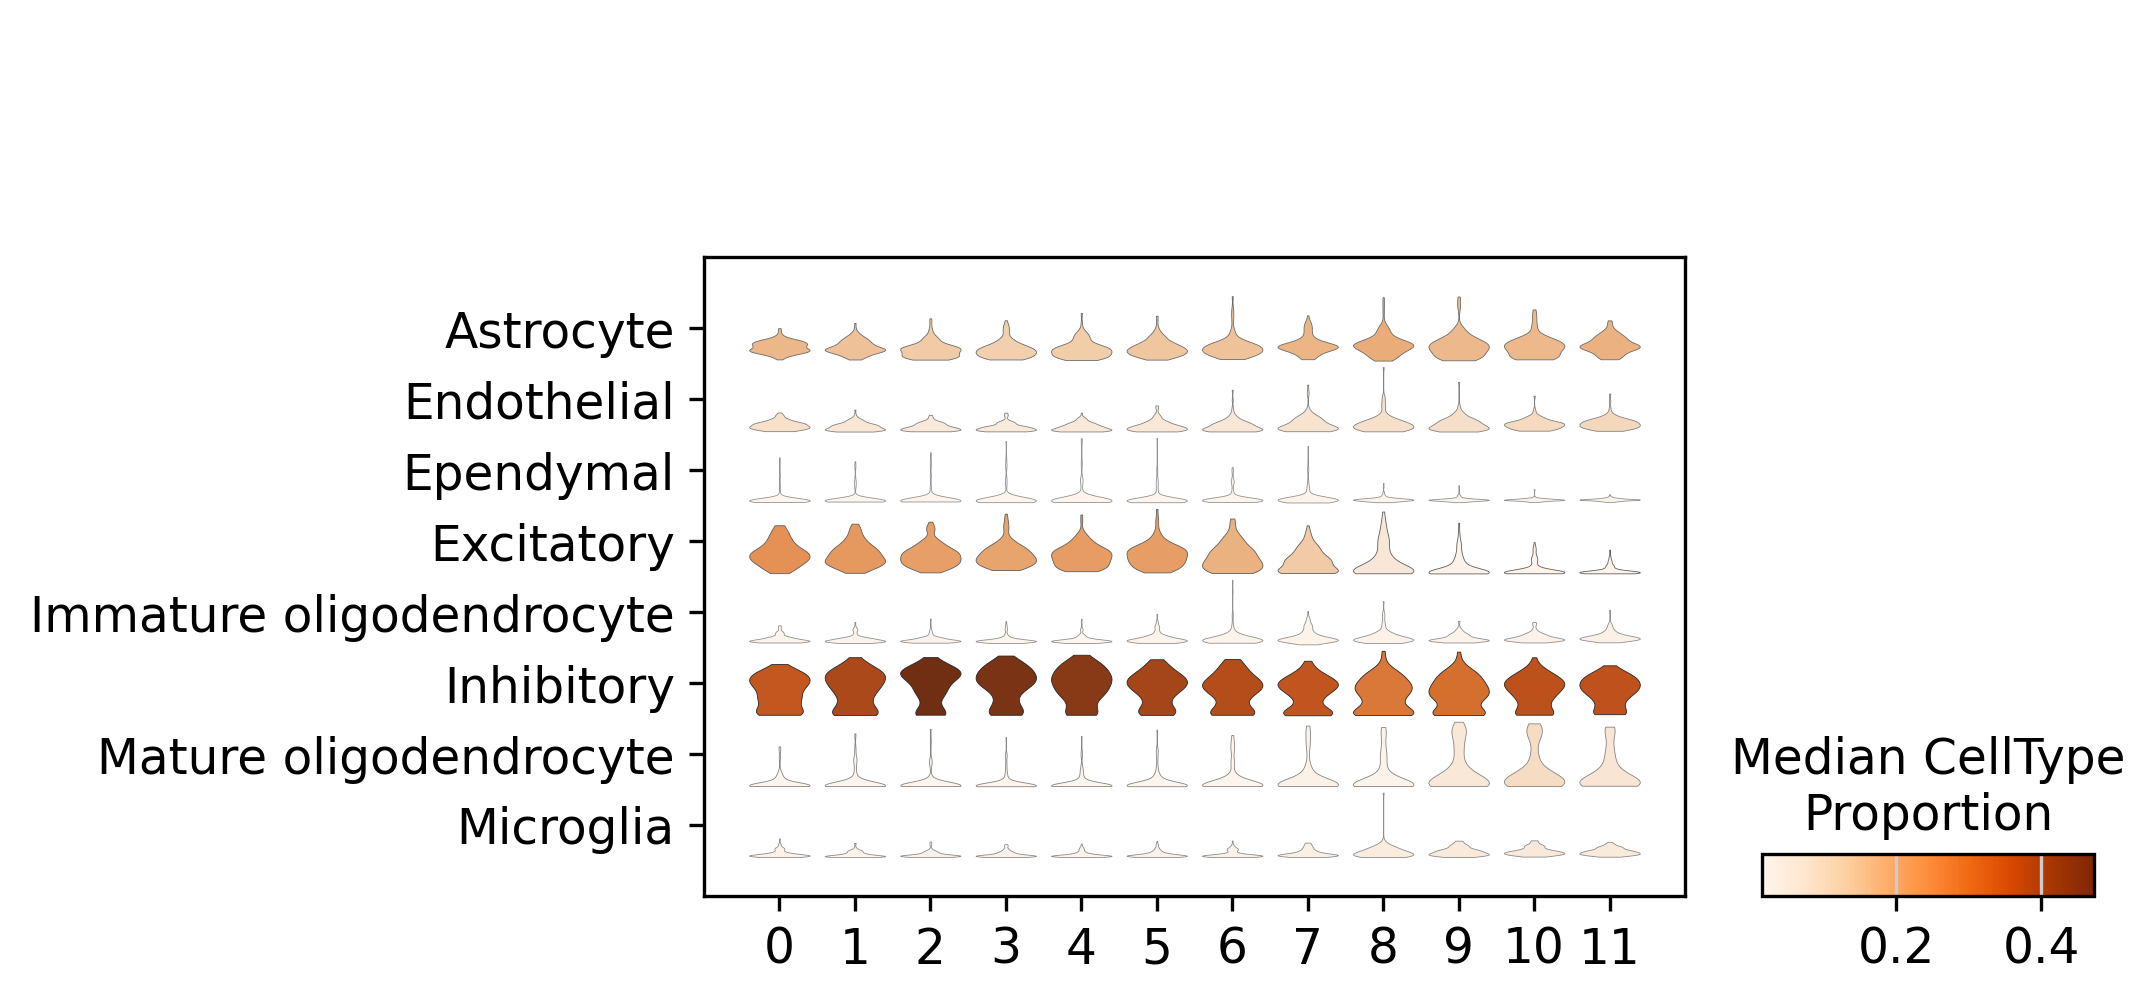

In [9]:
sc.pl.stacked_violin(
    adata_concat, adata_concat.var.index,cmap='Oranges',colorbar_title='Median CellType\nProportion', groupby="sample", swap_axes=True, save='_ctype_proportion.pdf' #dendrogram=True
)

## plot proportions

In [10]:
import anndata

adata_concat = adata_all['linear_0'][0]['0'].copy()
adata_concat.obs = all_algos['SpaDecoder']['0'][0].T
# adata_concat.obs['sample'] = '0'
# adata_concat.
slice_list = [adata_concat]
for realslice in slices[1:]:
    tmp_adata =  adata_all['linear_0'][0][str(realslice)].copy()
    tmp_adata.obs = all_algos['SpaDecoder'][str(realslice)][0].T
    # tmp_adata.obs['sample'] = str(realslice)
    slice_list.append(tmp_adata)
    # adata_concat = adata_concat.concatenate(tmp_adata)

In [11]:
for entry in slice_list:
    print(entry.obs.max().max())

0.693191
0.78543246
0.7864695
0.80730057
0.8180387
0.817124
0.773189
0.73728305
0.8714743
0.85975456
0.78421086
0.7019079


In [ ]:
cnt = 0
for entry in slice_list:
    for entry2 in ['Astrocyte', 'Endothelial', 'Ependymal', 'Excitatory', 'Immature oligodendrocyte', 'Inhibitory', 'Mature oligodendrocyte', 'Microglia']:
        entry3 = entry2 
        if ' ' in entry3:
            entry3 = entry3.replace(' ', '_')
        sc.pl.embedding(entry,basis='spatial',vmin=0, vmax=0.9,color=entry2, frameon=False, legend_loc=None, title=str(cnt) + ' ' + entry2, save='_' + str(cnt) + '_' + entry3 + '_prop.pdf')
    cnt = cnt + 1 

##  plot expression of key genes

In [17]:
genes_to_plot = ['Gad1','Slc17a6','Ttyh2','Pdgfra','Aqp4','Selplg','Cd24a','Fn1','Myh11']

In [ ]:
cnt = 0
for entry in slice_list:
    
    for entry2 in genes_to_plot: # ['Astrocyte', 'Endothelial', 'Ependymal', 'Excitatory', 'Immature oligodendrocyte', 'Inhibitory', 'Mature oligodendrocyte', 'Microglia']:
        sc.pp.log1p(entry)
        sc.pl.embedding(entry,basis='spatial',color=entry2, frameon=False, legend_loc='none', title=str(cnt) + ' ' + entry2, save='_' + str(cnt) + '_' + entry2 + '_gene.pdf')
    cnt = cnt + 1 